# Imports and Defs

In [1]:
import time as _time

import numpy as _np
import matplotlib.pyplot as plt

from mathphys.functions import load

from siriuspy.oscilloscope import Keysight, Scopes, ScopeSignals
from siriuspy.oscilloscope import Waveform, WaveformUtils

def plot_waveforms(wfms):
    for chan in wfms:
        plt.plot(1e6*wfms[chan][0], 1e3*wfms[chan][1], label=chan)
    plt.xlabel('time [µs]')
    plt.ylabel('Voltage [mV]')
    plt.grid()
    plt.legend()
    plt.tight_layout()
    plt.show()

# Test Scopes and ScopeSignals

In [2]:
print(ScopeSignals.LI_ICT1)

print(ScopeSignals.get_scopesignal('LI_ICT1'))
print(ScopeSignals.get_scopesignal(ScopeSignals.LI_ICT1))

print(ScopeSignals.get_channel(ScopeSignals.LI_ICT1))
print(ScopeSignals.get_channel(ScopeSignals.LI_ICT2))
print(ScopeSignals.get_channel(ScopeSignals.TB_ICT1))
print(ScopeSignals.get_channel(ScopeSignals.TB_ICT2))

('LI_ICT1', 'LI_DI_ICT', 'channel1')
('LI_ICT1', 'LI_DI_ICT', 'channel1')
('LI_ICT1', 'LI_DI_ICT', 'channel1')
channel1
channel2
channel3
channel4


In [3]:
print(Scopes.LI_DI_ICT)

scopename      : LI_DI_ICT
ipaddr         : 10.128.1.150
hostname       : li-di-ictosc.lnls-sirius.com.br
port           : 5025
channel1       : LI_ICT1
channel2       : LI_ICT2
channel3       : TB_ICT1
channel4       : TB_ICT2
stats_fields   : ('CURR', 'MEAN', 'MIN', 'MAX', 'RANGE', 'STD', 'COUNT')


In [4]:
scope = Scopes.get_scope(ScopeSignals.LI_ICT1)
print(scope)

scopename      : LI_DI_ICT
ipaddr         : 10.128.1.150
hostname       : li-di-ictosc.lnls-sirius.com.br
port           : 5025
channel1       : LI_ICT1
channel2       : LI_ICT2
channel3       : TB_ICT1
channel4       : TB_ICT2
stats_fields   : ('CURR', 'MEAN', 'MIN', 'MAX', 'RANGE', 'STD', 'COUNT')


In [6]:
print(Scopes.get_scope(ScopeSignals.LI_MODLTR1))

scopename      : LI_PU_MODLTR
ipaddr         : 10.128.150.20
hostname       : KEYSIGH-QQI8MNR.abtlus.org.br
port           : 5025
channel1       : LI_MODLTR1
channel2       : None
channel3       : LI_MODLTR2
channel4       : None
stats_fields   : ('CURR', 'MEAN', 'MIN', 'MAX', 'RANGE', 'STD', 'COUNT')


# Test Keysight

In [7]:
scope = Scopes.TS_PU_EJEBO; print(f'{scope.scopename:<20s} : {scope.get_identification()}')
scope = Scopes.LI_PU_MODLTR; print(f'{scope.scopename:<20s} : {scope.get_identification()}')
scope = Scopes.TS_PU_INJSI; print(f'{scope.scopename:<20s} : {scope.get_identification()}')
scope = Scopes.AS_DI_FCT; print(f'{scope.scopename:<20s} : {scope.get_identification()}')
scope = Scopes.AS_DI_FPM; print(f'{scope.scopename:<20s} : {scope.get_identification()}')
scope = Scopes.TB_PU_INJBO; print(f'{scope.scopename:<20s} : {scope.get_identification()}')
scope = Scopes.LI_DI_ICT; print(f'{scope.scopename:<20s} : {scope.get_identification()}')
scope = Scopes.SI_PU_INJSI; print(f'{scope.scopename:<20s} : {scope.get_identification()}')

TS_PU_EJEBO          : KEYSIGHT TECHNOLOGIES,DSOS054A,MY57500104,06.75.00010
LI_PU_MODLTR         : KEYSIGHT TECHNOLOGIES,DSOS104A,MY57500105,06.50.01004
TS_PU_INJSI          : KEYSIGHT TECHNOLOGIES,DSOS054A,MY57500106,06.75.00010
AS_DI_FCT            : KEYSIGHT TECHNOLOGIES,DSOS104A,MY57500107,06.74.00204
AS_DI_FPM            : KEYSIGHT TECHNOLOGIES,DSOS104A,MY57500108,06.10.00804
TB_PU_INJBO          : KEYSIGHT TECHNOLOGIES,DSOS054A,MY57500109,06.75.00010
LI_DI_ICT            : KEYSIGHT TECHNOLOGIES,DSOS104A,MY57500110,06.74.01101
SI_PU_INJSI          : KEYSIGHT TECHNOLOGIES,DSOS054A,MY57500111,06.75.00010


In [8]:
k = Scopes.LI_DI_ICT
print(k)

scopename      : LI_DI_ICT
ipaddr         : 10.128.1.150
hostname       : li-di-ictosc.lnls-sirius.com.br
port           : 5025
channel1       : LI_ICT1
channel2       : LI_ICT2
channel3       : TB_ICT1
channel4       : TB_ICT2
stats_fields   : ('CURR', 'MEAN', 'MIN', 'MAX', 'RANGE', 'STD', 'COUNT')


In [9]:
t0 = _time.time()
idn = k.get_identification()
t1 = _time.time()
print(f'time: {1e3*(t1-t0):.3f} ms')

time: 91.999 ms


In [10]:
idn

'KEYSIGHT TECHNOLOGIES,DSOS104A,MY57500110,06.74.01101'

In [11]:
t0 = _time.time()
k.channel_select('channel1')
t1 = _time.time()
print(f'time: {1e3*(t1-t0):.3f} ms')

time: 1.031 ms


In [12]:
t0 = _time.time()
k.scales_read('channel1')
t1 = _time.time()
print(f'time: {1e3*(t1-t0):.3f} ms')

time: 250.231 ms


In [13]:
print(k.channels_scales)

{'channel1': (2.5e-11, 5.26875e-06, 0.0917109)}


In [14]:
t0 = _time.time()
k.scales_update_all()
t1 = _time.time()
print(f'time: {1e3*(t1-t0):.3f} ms')

time: 1034.997 ms


In [15]:
print(k.channels_scales)

{'channel1': (2.5e-11, 5.26875e-06, 0.0917109), 'channel2': (2.5e-11, 5.2692e-06, 0.0821114), 'channel3': (2.5e-11, 5.26945e-06, 0.00531161), 'channel4': (2.5e-11, 5.27047e-06, 0.00531263)}


In [16]:
t0 = _time.time()
k.wfm_config()
t1 = _time.time()
print(f'time: {1e3*(t1-t0):.3f} ms')

time: 0.604 ms


In [17]:
t0 = _time.time()
k.wfm_read_raw()
t1 = _time.time()
print(f'time: {1e3*(t1-t0):.3f} ms')

time: 593.866 ms


In [18]:
t0 = _time.time()
datax, datay = k.wfm_read_channel('channel1')
t1 = _time.time()
print(f'time: {1e3*(t1-t0):.3f} ms')

time: 867.193 ms


In [20]:
t0 = _time.time()
data = k.wfm_read()
t1 = _time.time()
print(f'time: {1e3*(t1-t0):.3f} ms')

time: 702.052 ms


In [21]:
k.meas_read()

{'Charge-TB-ICT2': {'CURR': 1.91676e-09,
  'MEAN': 0.0,
  'MIN': 1.91676e-09,
  'MAX': 1.91676e-09,
  'RANGE': 1.91676e-09,
  'STD': 0.0,
  'COUNT': 1.0},
 'Charge-TB-ICT1': {'CURR': 1.06913e-09,
  'MEAN': 0.0,
  'MIN': 1.06913e-09,
  'MAX': 1.06913e-09,
  'RANGE': 1.06913e-09,
  'STD': 0.0,
  'COUNT': 1.0},
 'Charge-LI-ICT2': {'CURR': 1.27981e-09,
  'MEAN': 0.0,
  'MIN': 1.27981e-09,
  'MAX': 1.27981e-09,
  'RANGE': 1.27981e-09,
  'STD': 0.0,
  'COUNT': 1.0},
 'Charge-LI-ICT1': {'CURR': 1.298e-09,
  'MEAN': 0.0,
  'MIN': 1.298e-09,
  'MAX': 1.298e-09,
  'RANGE': 1.298e-09,
  'STD': 0.0,
  'COUNT': 1.0}}

In [12]:
print(data)

{'LI_ICT1': (array([0.00000e+00, 2.50000e-11, 5.00000e-11, ..., 5.00150e-07,
       5.00175e-07, 5.00200e-07]), array([ 0.00087765,  0.00087765,  0.0008355 , ..., -0.00148275,
       -0.0014406 , -0.0015249 ])), 'LI_ICT2': (array([0.00000e+00, 2.50000e-11, 5.00000e-11, ..., 5.00150e-07,
       5.00175e-07, 5.00200e-07]), array([0.00227248, 0.00231464, 0.00223033, ..., 0.00096572, 0.00079711,
       0.00079711])), 'TB_ICT1': (array([0.00000e+00, 2.50000e-11, 5.00000e-11, ..., 5.00150e-07,
       5.00175e-07, 5.00200e-07]), array([ 8.431560e-05,  4.216000e-05, -4.215120e-05, ..., -3.793960e-04,
       -3.793960e-04, -4.637072e-04])), 'TB_ICT2': (array([0.00000e+00, 2.50000e-11, 5.00000e-11, ..., 5.00150e-07,
       5.00175e-07, 5.00200e-07]), array([0.00805327, 0.00809544, 0.00809544, ..., 0.00796895, 0.00792678,
       0.00788462]))}


In [22]:
t0 = _time.time()
k.scales_update_all()
t1 = _time.time()
print(f'time: {1e3*(t1-t0):.3f} ms')

time: 854.374 ms


In [23]:
for _ in range(10):
    t0 = _time.time()
    meas, wfms = k.acquire(acq_meas=True, acq_wfms=True)
    t1 = _time.time()
    print(f'time: {1e3*(t1-t0):.3f} ms')

time: 640.624 ms
time: 1354.158 ms
time: 1191.571 ms
time: 1192.784 ms
time: 1202.634 ms
time: 1245.268 ms
time: 1191.725 ms
time: 1110.932 ms
time: 1287.078 ms
time: 1150.764 ms


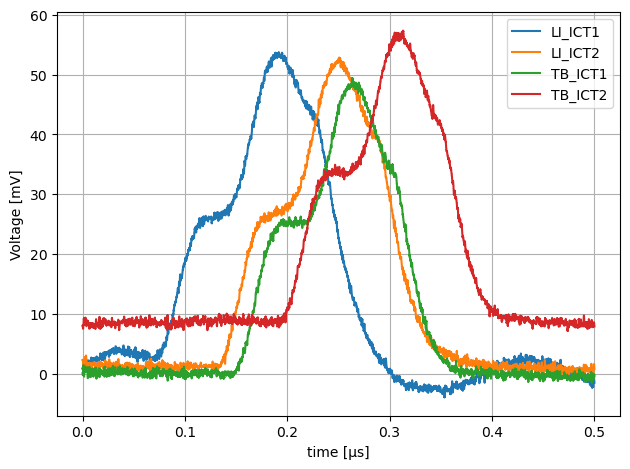

In [24]:
plot_waveforms(wfms)

In [25]:
t0 = _time.time()
dr = k.setup_fetch()
t1 = _time.time()
print(f'time: {1e3*(t1-t0):.3f} ms')

time: 508.469 ms


In [26]:
t0 = _time.time()
drc = k.setup_compress(dr)
t1 = _time.time()
print(f'time: {1e3*(t1-t0):.3f} ms')

time: 326.741 ms


In [27]:
t0 = _time.time()
drdc = k.setup_decompress(drc)
t1 = _time.time()
print(f'time: {1e3*(t1-t0):.3f} ms')

time: 5.163 ms


In [28]:
len(dr), len(drc), len(drdc)

(2438333, 68252, 2438333)

In [13]:
k.setup_apply(drdc)

# WfmProcess

In [2]:
nrpts = 10000

tim_gauss, wfm_gauss = WfmTools.gen_gauss(nrpts=nrpts, sigma=0.1)
tim_gauss2, wfm_gauss2 = WfmTools.gen_gauss(nrpts=nrpts, sigma=0.05, avg=0.7)
tim_sin, wfm_sin = WfmTools.gen_sine(nrpts=nrpts, frequency=4, amplitude=0.05)
tim_cos, wfm_cos = WfmTools.gen_sine(nrpts=nrpts, frequency=4, amplitude=0.05, phase=_np.pi/2)
tim_uni, wfm_uni = WfmTools.gen_uniform(nrpts, amplitude=0.5)

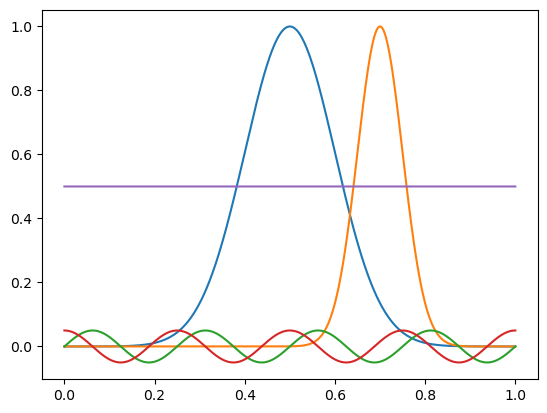

In [3]:
plt.plot(tim_gauss, wfm_gauss)
plt.plot(tim_gauss2, wfm_gauss2)
plt.plot(tim_sin, wfm_sin)
plt.plot(tim_cos, wfm_cos)
plt.plot(tim_uni, wfm_uni)
plt.show()

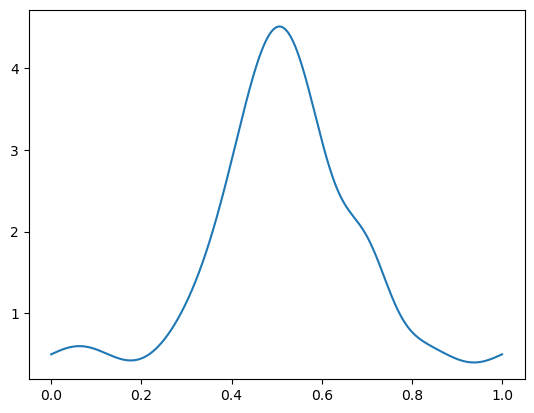

In [4]:
wfms = (wfm_uni, wfm_sin, wfm_cos, wfm_gauss, wfm_gauss2)
weights = (1, 2, 0, 4, 1)

tim_tot = tim_uni
wfm_tot = 0 * wfm_uni
for w, wfm in zip(weights, wfms):
    wfm_tot += w  *wfm

wfm = WfmProcess(tim_tot, wfm_tot)
plt.plot(wfm.tim, wfm.wfm)
plt.show()

In [5]:
coeffs, residues, rank, s = wfm.fit_linear_coeffs(wfms)

In [6]:
coeffs

array([1.0000000e+00, 2.0000000e+00, 7.8138044e-15, 4.0000000e+00,
       1.0000000e+00])

# From Measurements

In [3]:
ls /home/ximenes.resende/shared/screens-iocs/data_by_day/ | grep scope

2026-07-03-AS_scope_li_tb_ict_tests/
2026-07-17-AS_scope_li_tb_ict_tests/
2026-07-20-AS_scope_li_tb_ict_tests/
2026-07-27-AS_scope_li_tb_ict_tests/
2026-08-03-AS_scope_li_tb_ict_tests/
2026-08-10-AS_scope_li_tb_ict_tests/
2026-08-11-AS_scope_li_tb_ict_tests/
2026-08-18-AS_scope_li_tb_ict_tests/
2026-08-24-AS_scope_li_tb_ict_tests/
2026-09-12-AS_scope_li_tb_ict_tests/


In [2]:
ls /home/ximenes.resende/shared/screens-iocs/data_by_day/2026-08-11-AS_scope_li_tb_ict_tests/

acquisition.ipynb  test_li_tb_scope_no_split_tb_50_ohm_01.pickle
analysis.ipynb     test_li_tb_scope_split_tb_1M_ohm_01.pickle


In [2]:
data = load('/home/ximenes.resende/shared/screens-iocs/data_by_day/2026-08-11-AS_scope_li_tb_ict_tests/test_li_tb_scope_split_tb_1M_ohm_01.pickle')

In [3]:
len(data)

26

In [3]:
def fit_signal(wfm_sig, wfm_pul, period):
    nrpts = len(wfm_sig.wfm)
    tim_init, tim_final = wfm_sig.tim[0], wfm_sig.tim[-1]
    wfm_ = WaveformUtils.gen_uniform(nrpts, tim_init=tim_init, tim_final=tim_final)
    wfm_uni = Waveform(*wfm_)
    wfm_ = WaveformUtils.gen_sine(nrpts, period=period, tim_init=tim_init, tim_final=tim_final, phase=0)
    wfm_sin = Waveform(*wfm_)
    wfm_ = WaveformUtils.gen_sine(nrpts, period=period, tim_init=tim_init, tim_final=tim_final, phase=_np.pi/2)
    wfm_cos = Waveform(*wfm_)

    wfms = [wfm_pul, wfm_uni, wfm_sin, wfm_cos]
    coeffs, residues, wfm_fit, *_ = wfm_sig.fit_linear_coeffs(wfms)
    nresidues = _np.sqrt(residues / len(wfm_sig.wfm))
    
    return coeffs, residues, wfm_fit, wfms

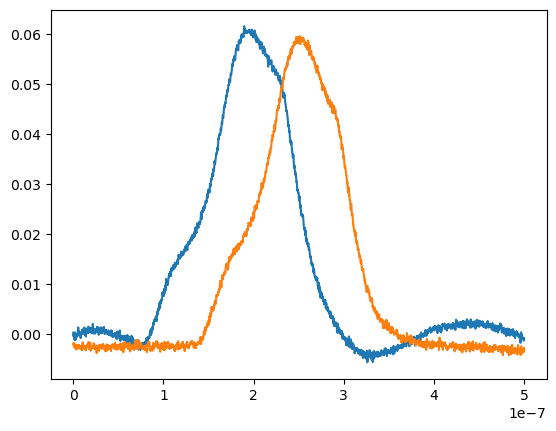

wfm_ict1 size    : 20009
wfm_ict1 max_idx : 7583
wfm_ict2 size    : 20009
wfm_ict2 max_idx : 10045
shift            : 2462


In [4]:
wfm_sig = Waveform(*data[0]['channel_LI_ICT1_wfm'])
wfm_ = Waveform(*data[0]['channel_LI_ICT2_wfm'])

plt.plot(wfm_sig.tim, wfm_sig.wfm)
plt.plot(wfm_.tim, wfm_.wfm)
plt.show()

shift = wfm_.wfm_idx_max - wfm_sig.wfm_idx_max

print(f'wfm_ict1 size    : {len(wfm_sig.wfm)}')
print(f'wfm_ict1 max_idx : {wfm_sig.wfm_idx_max}')
print(f'wfm_ict2 size    : {len(wfm_.wfm)}')
print(f'wfm_ict2 max_idx : {wfm_.wfm_idx_max}')
print(f'shift            : {shift}')

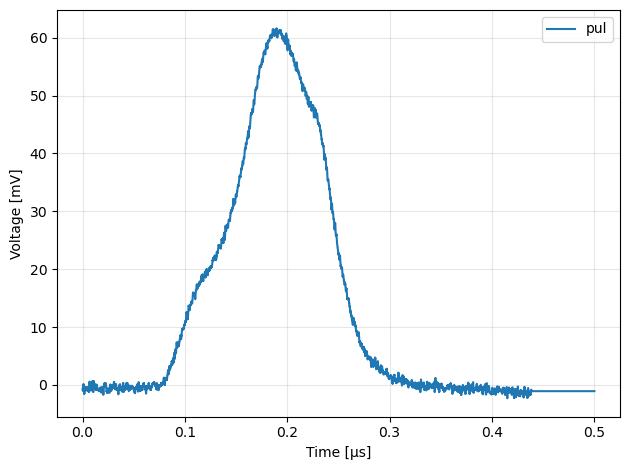

In [5]:
# cria waveform de pulso a partir da waveform do ICT2, deslocada para o time-of-flight da ICT1

wfm_pul = Waveform(wfm_.tim, WaveformUtils.shift_left(wfm_.wfm, shift)) + 0.002
plt.plot(1e6*wfm_pul.tim, 1e3*wfm_pul.wfm, label='pul')
plt.xlabel('Time [µs]')
plt.ylabel('Voltage [mV]')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [6]:
period = 0.2125e-6
periods = _np.linspace(0.999*period, 1.001*period, 15)
for period in periods:
    coeffs, residues, wfm_fit, wfms = fit_signal(wfm_sig, wfm_pul, period=period)
    print(f'period: {1e6*period:.6f} µs, residue: {residues[0]:.8f}')

period: 0.212288 µs, residue: 0.03767383
period: 0.212318 µs, residue: 0.03767356
period: 0.212348 µs, residue: 0.03767334
period: 0.212379 µs, residue: 0.03767316
period: 0.212409 µs, residue: 0.03767303
period: 0.212439 µs, residue: 0.03767293
period: 0.212470 µs, residue: 0.03767288
period: 0.212500 µs, residue: 0.03767288
period: 0.212530 µs, residue: 0.03767291
period: 0.212561 µs, residue: 0.03767299
period: 0.212591 µs, residue: 0.03767312
period: 0.212621 µs, residue: 0.03767328
period: 0.212652 µs, residue: 0.03767349
period: 0.212682 µs, residue: 0.03767374
period: 0.212712 µs, residue: 0.03767403


In [7]:
period = 0.2125e-6
coeffs, residues, wfm_fit, wfms = fit_signal(wfm_sig, wfm_pul, period=period)

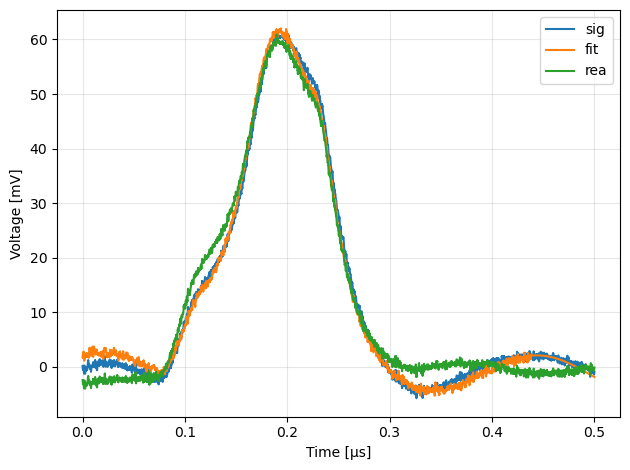

charge sig: 1.238 nC
charge fit: 1.238 nC
charge rea: 1.246 nC


In [8]:
# wfm6 = WfmProcess(wfm1.tim, wfm_fit)

wfm_pul, wfm_uni, wfm_sin, wfm_cos = wfms

wfm_per = coeffs[1] * wfm_uni + coeffs[2] * wfm_sin + coeffs[3] * wfm_cos
wfm_rea = wfm_sig - wfm_per

plt.plot(1e6*wfm_sig.tim, 1e3*wfm_sig.wfm, label='sig')
plt.plot(1e6*wfm_fit.tim, 1e3*wfm_fit.wfm, label='fit')
plt.plot(1e6*wfm_rea.tim, 1e3*wfm_rea.wfm, label='rea')
plt.xlabel('Time [µs]')
plt.ylabel('Voltage [mV]')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'charge sig: {1e9*wfm_sig.calc_integral():.3f} nC')
print(f'charge fit: {1e9*wfm_fit.calc_integral():.3f} nC')
print(f'charge rea: {1e9*wfm_rea.calc_integral():.3f} nC')